In [1]:
import pandas as pd

df=pd.read_csv("/content/medical_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [4]:
print("Shape :",df.shape)

Shape : (2772, 7)


In [3]:
# check duplicates
print("Duplicate rows: ",df.duplicated().sum())

Duplicate rows:  1435


In [5]:
# remove duplicated rows
df=df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates :",df.shape)
print("Duplicate rows :",df.duplicated().sum())

Shape after removing duplicates : (1337, 7)
Duplicate rows : 0


In [7]:
# check the missing value
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [10]:
print((df.isnull().sum()/len(df)*100).round(2))

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


In [11]:
# descriptive statistics
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
# check categorial features

categorical_features=df.select_dtypes(include="object").columns

for col in categorical_features:
  print("\n" + "=" * 50)
  print(f"Column :{col}")
  print("Unique Values :",df[col].nunique())
  print(df[col].value_counts())


Column :sex
Unique Values : 2
sex
male      675
female    662
Name: count, dtype: int64

Column :smoker
Unique Values : 2
smoker
no     1063
yes     274
Name: count, dtype: int64

Column :region
Unique Values : 4
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [13]:
# check numerical relationships
correlation = df.select_dtypes(include="number").corr()

print(correlation['charges'].sort_values(ascending=False))

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


In [16]:
print("Average charges by smoker:")
print(df.groupby("smoker")["charges"].agg(["count","mean","median"]))

Average charges by smoker:
        count          mean       median
smoker                                  
no       1063   8440.660307   7345.72660
yes       274  32050.231832  34456.34845


In [17]:
print("\nAverage charges by sex:")
print(df.groupby("sex")['charges'].agg(["count","mean","median"]))

print("\nAverage charges by region:")
print(df.groupby("region")['charges'].agg(["count","mean","median"]))


Average charges by sex:
        count          mean     median
sex                                   
female    662  12569.578844  9412.9625
male      675  13974.998864  9377.9047

Average charges by region:
           count          mean        median
region                                      
northeast    324  13406.384516  10057.652025
northwest    324  12450.840844   8976.977250
southeast    364  14735.411438   9294.131950
southwest    325  12346.937377   8798.593000


Define features and target

In [18]:
y=df['charges']

In [19]:
x=df.drop(columns=['charges'])

print("x Shape: ",x.shape)
print("y shape: ",y.shape)

x Shape:  (1337, 6)
y shape:  (1337,)


Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("x_train:",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

x_train: (1069, 6)
x_test (268, 6)
y_train (1069,)
y_test (268,)


Separate Feature Types

In [23]:
numerical_features=x_train.select_dtypes(
    include=['int64','float64']
).columns.tolist()

categorical_features=x_train.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features :")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features :
['age', 'bmi', 'children']

Categorical Features:
['sex', 'smoker', 'region']


create the preprocessing pipeline

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

preprocessor=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


Train the Baseline Elastic Net Model

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet

elastic_net_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",ElasticNet(
            alpha=1.0,
            l1_ratio=0.5,
            random_state=42,
            max_iter=10000
        )
      )
    ]
)

elastic_net_pipeline.fit(x_train,y_train)
print("Elastic Net Model Train Successfully")

Elastic Net Model Train Successfully


In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

y_pred = elastic_net_pipeline.predict(x_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("Elastic Net Regression")
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)

Elastic Net Regression
MAE : 6893.384932529948
MSE : 93410717.33246475
RMSE : 9664.922003434107
R2 Score : 0.4916591307072605


Tune Elastic Net

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__alpha': 0.001, 'model__l1_ratio': 0.9}

Best CV MAE:
4207.106283169821


In [39]:
best_elastic_net = grid_search.best_estimator_

y_pred_tuned = best_elastic_net.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
mse = mean_squared_error(y_test, y_pred_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned)

print("\nTuned Elastic Net Regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


Tuned Elastic Net Regression
MAE : 4177.942086680163
MSE : 35488082.16603179
RMSE: 5957.187437543978
R²  : 0.8068739535142937


Let's check which features Elastic Net retained and which coefficients were pushed toward zero.

In [46]:
# get the trained Elastic Net Model
elastic_model = best_elastic_net.named_steps["model"]

# get feature name after preprocessing
feature_names = best_elastic_net.named_steps[
    "preprocessor"
].get_feature_names_out()

# get coefficients
coefficients = elastic_model.coef_

# create coefficient Dataframe
coef_df = pd.DataFrame({
    "Feature":feature_names,
    "Coefficient":coefficients
})

# Absolute coefficient
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

print(coef_df)

                  Feature   Coefficient  Abs_Coefficient
5          cat__smoker_no -11541.860035     11541.860035
6         cat__smoker_yes  11528.508281     11528.508281
0                num__age   3472.565009      3472.565009
1                num__bmi   1927.503820      1927.503820
2           num__children    636.524620       636.524620
7   cat__region_northeast    472.602281       472.602281
9   cat__region_southeast   -365.450494       365.450494
10  cat__region_southwest   -186.415748       186.415748
8   cat__region_northwest     80.678848        80.678848
3         cat__sex_female     50.934108        50.934108
4           cat__sex_male    -50.082446        50.082446


Now, check how many coefficients became zero:

In [47]:
zero_coefficients = (coefficients == 0).sum()
total_coefficients = len(coefficients)

print("Zero coefficients:", zero_coefficients)
print("Total coefficients:", total_coefficients)

print(
    "Percentage of coefficients removed:",
    (zero_coefficients / total_coefficients) * 100
)

Zero coefficients: 0
Total coefficients: 11
Percentage of coefficients removed: 0.0


In [48]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(coef_df)

                  Feature   Coefficient  Absolute_Coefficient
5          cat__smoker_no -11541.860035          11541.860035
6         cat__smoker_yes  11528.508281          11528.508281
0                num__age   3472.565009           3472.565009
1                num__bmi   1927.503820           1927.503820
2           num__children    636.524620            636.524620
7   cat__region_northeast    472.602281            472.602281
9   cat__region_southeast   -365.450494            365.450494
10  cat__region_southwest   -186.415748            186.415748
8   cat__region_northwest     80.678848             80.678848
3         cat__sex_female     50.934108             50.934108
4           cat__sex_male    -50.082446             50.082446


## Actual vs Predicted

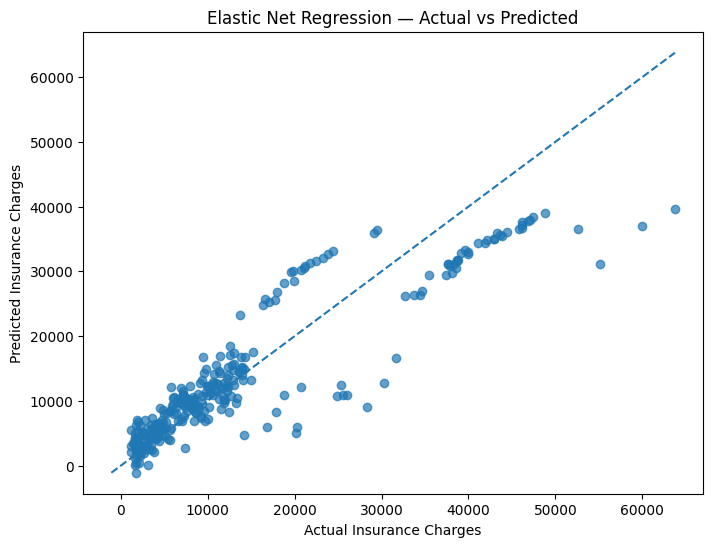

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_tuned.min())
max_value = max(y_test.max(), y_pred_tuned.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Elastic Net Regression — Actual vs Predicted")

plt.show()

## Test With New Customers

In [50]:
new_customers = pd.DataFrame({
    "age": [25, 40, 55, 32, 60],
    "sex": ["female", "male", "female", "male", "female"],
    "bmi": [24.5, 31.2, 28.7, 26.4, 35.1],
    "children": [0, 2, 1, 3, 2],
    "smoker": ["no", "yes", "no", "no", "yes"],
    "region": ["northeast", "southeast", "northwest", "southwest", "southeast"]
})

new_predictions = best_elastic_net.predict(new_customers)

prediction_df = new_customers.copy()

prediction_df["Predicted Charges"] = new_predictions

prediction_df

,age,sex,bmi,children,smoker,region,Predicted Charges
0,25,female,24.5,0,no,northeast,2922.507674
1,40,male,31.2,2,yes,southeast,31977.526882
2,55,female,28.7,1,no,northwest,11847.376015
3,32,male,26.4,3,no,southwest,6104.262419
4,60,female,35.1,2,yes,southeast,38284.897464


In [51]:
import joblib

joblib.dump(
    best_elastic_net,
    "day6_elastic_net_insurance_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
